In [79]:
# import libraries
import pandas as pd
import numpy as np

# Machine learning packages
from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso, Ridge
from sklearn.linear_model import RidgeCV, LassoCV, LogisticRegressionCV # CV objects

from sklearn.metrics import root_mean_squared_error, mean_absolute_error # regression
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, roc_auc_score

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import cross_val_score, cross_val_predict, cross_validate
import matplotlib.pyplot as plt


## Goal

The goal of this project is to predict whether a customer will subscribe to a term deposit using demographic and campaign-related features.

In [74]:
# loading load
train = pd.read_csv('bank_marketing_train.csv')  
test = pd.read_csv('bank_marketing_test.csv') 
train.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [75]:
# ------------Data preparation-----------------

train['y'] = train['y'].map({'yes': 1, 'no': 0})
test['y'] = test['y'].map({'yes': 1, 'no': 0})

X_train = train.drop('y', axis=1)
X_test = test.drop('y', axis=1)

y_train = train['y']
y_test = test['y']

combined = pd.concat([X_train, X_test])
combined = pd.get_dummies(combined, drop_first=True)
X_train = combined.iloc[:len(X_train), :]
X_test = combined.iloc[len(X_train):, :]

feature_names = X_train.columns 
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df  = pd.DataFrame(X_test, columns=feature_names)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### Tunning and train model unregularized

In [50]:
lasso_logistic = LogisticRegression(penalty=None, solver='lbfgs',max_iter=1000,random_state=42)
lasso_logistic.fit(X_train, y_train)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Regularized results and metrics 

In [51]:
# Predicted labels
y_pred_train = lasso_logistic.predict(X_train)
y_pred_test = lasso_logistic.predict(X_test)

y_prob_train = lasso_logistic.predict_proba(X_train)[:,1]
y_prob_test = lasso_logistic.predict_proba(X_test)[:,1]

# Train metrics
train_acc = accuracy_score(y_train, y_pred_train)
train_prec = precision_score(y_train, y_pred_train)
train_rec = recall_score(y_train, y_pred_train)

# Test metrics
test_acc = accuracy_score(y_test, y_pred_test)
test_prec = precision_score(y_test, y_pred_test)
test_rec = recall_score(y_test, y_pred_test)

print(f"Train -> Accuracy: {train_acc:.3f}, Precision: {train_prec:.3f}, Recall: {train_rec:.3f}")
print(f"Test  -> Accuracy: {test_acc:.3f}, Precision: {test_prec:.3f}, Recall: {test_rec:.3f}")

Train -> Accuracy: 0.911, Precision: 0.667, Recall: 0.423
Test  -> Accuracy: 0.915, Precision: 0.694, Recall: 0.444


The model achieves 91.5% accuracy, but recall for the minority class (subscribers) is lower at 44%, indicating the model tends to underpredict actual subscriptions.

### Filtering out noise and unnecesarry precidtors using lasso

In [42]:
Cs = np.logspace(0, -2.5, 20)
lcv = LogisticRegressionCV(Cs=Cs, cv=10, penalty='l1', solver='liblinear', max_iter=1000)
lcv.fit(X_train, y_train)

,Cs,"array([1. ..., 0.00316228])"
,fit_intercept,True
,cv,10
,dual,False
,penalty,'l1'
,scoring,None
,solver,'liblinear'
,tol,0.0001
,max_iter,1000
,class_weight,None
,n_jobs,None


In [46]:
print("Best C (inverse of regularization strength):", lcv.C_[0])
y_pred_train = lcv.predict(X_train)
y_pred_test = lcv.predict(X_test)

# predicted probabilities for threshold tuning
y_prob_train = lcv.predict_proba(X_train)[:,1]
y_prob_test = lcv.predict_proba(X_test)[:,1]

print("Train -> Accuracy:", accuracy_score(y_train, y_pred_train),
      "Precision:", precision_score(y_train, y_pred_train),
      "Recall:", recall_score(y_train, y_pred_train), 
      "Roc_auc:", roc_auc_score(y_test, y_prob_test))
print("Test  -> Accuracy:", accuracy_score(y_test, y_pred_test),
      "Precision:", precision_score(y_test, y_pred_test),
      "Recall:", recall_score(y_test, y_pred_test),
      "Roc_auc:", roc_auc_score(y_test, y_prob_test))

cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:\n", cm)

Best C (inverse of regularization strength): 0.0031622776601683794
Train -> Accuracy: 0.906558222815696 Precision: 0.6663163426169206 Recall: 0.3415948275862069 Roc_auc: 0.938300265143116
Test  -> Accuracy: 0.9096758528590506 Precision: 0.6900826446280992 Recall: 0.3599137931034483 Roc_auc: 0.938300265143116
Confusion Matrix:
 [[7159  150]
 [ 594  334]]


In [69]:
coefficients = lcv.coef_[0]
eliminated_predictors = [f for f, c in zip(feature_names, coefficients) if c == 0]
selected_predictors   = [f for f, c in zip(feature_names, coefficients) if c != 0]

print("Eliminated features:", eliminated_predictors, '\n')
print("Selected features:", selected_predictors)

selected_idx = [i for i, c in enumerate(coefficients) if c != 0]

X_train_selected = X_train_df[selected_predictors]
X_test_selected  = X_test_df[selected_predictors]

Eliminated features: ['age', 'campaign', 'previous', 'cons.price.idx', 'euribor3m', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'marital_unknown', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'education_unknown', 'default_unknown', 'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent'] 

Selected features: ['duration', 'pdays', 'emp.var.rate', 'cons.conf.idx', 'nr.employed', 'job_blue-collar', 'month_mar', 'month_may', 'poutcome_success']


In [71]:
X_train_selected.head()

,duration,pdays,emp.var.rate,cons.conf.idx,nr.employed,job_blue-collar,month_mar,month_may,poutcome_success
0,261,999,1.1,-36.4,5191.0,False,False,True,False
1,149,999,1.1,-36.4,5191.0,False,False,True,False
2,226,999,1.1,-36.4,5191.0,False,False,True,False
3,151,999,1.1,-36.4,5191.0,False,False,True,False
4,198,999,1.1,-36.4,5191.0,False,False,True,False


In [76]:
X_train_sel_scaled = scaler.fit_transform(X_train_selected)
X_test_sel_scaled = scaler.transform(X_test_selected)

log_sel = LogisticRegression(penalty=None, solver='saga', max_iter=1000, random_state=42)
log_sel.fit(X_train_sel_scaled, y_train)

y_pred_test_sel = log_sel.predict(X_test_sel_scaled)
y_prob_test_sel = log_sel.predict_proba(X_test_sel_scaled)[:,1]

print("Test Accuracy:", accuracy_score(y_test, y_pred_test_sel))
print("Test Precision:", precision_score(y_test, y_pred_test_sel))
print("Test Recall:", recall_score(y_test, y_pred_test_sel))
print("Test Roc AUC:", roc_auc_score(y_test, y_prob_test_sel))

Test Accuracy: 0.909554449435474
Test Precision: 0.660245183887916
Test Recall: 0.40625
Test Roc AUC: 0.9393424674822255


The model achieves high overall accuracy (91%) and excellent discrimination (ROC AUC ≈ 0.94), but recall for actual subscribers is relatively low at 41%, indicating many potential subscribers are missed. Precision is moderate (66%), so some false positives exist, but given the goal of identifying as many subscribers as possible, recall is the key metric to improve.

### Finding the best thresehold

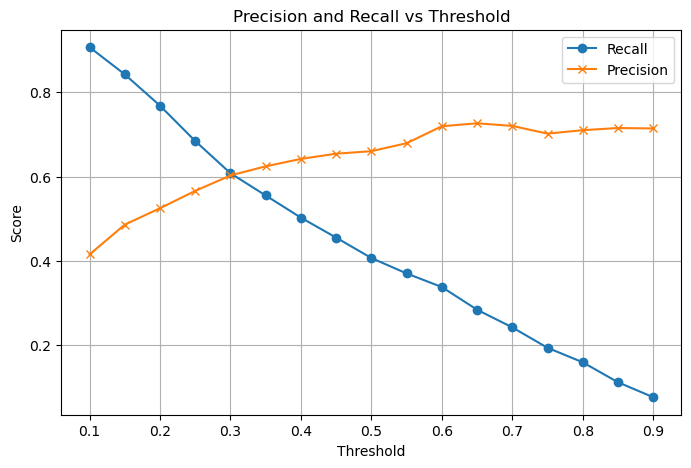

In [80]:
thresholds = np.arange(0.1, 0.91, 0.05)
recalls = []
precisions = []

for t in thresholds:
    y_pred_thresh = (y_prob_test_sel >= t).astype(int)
    recalls.append(recall_score(y_test, y_pred_thresh))
    precisions.append(precision_score(y_test, y_pred_thresh))

plt.figure(figsize=(8,5))
plt.plot(thresholds, recalls, label='Recall', marker='o')
plt.plot(thresholds, precisions, label='Precision', marker='x')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

In [83]:
thresholds = np.arange(0.1, 0.91, 0.01) 
results = []

for t in thresholds:
    y_pred_thresh = (y_prob_test_sel >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_thresh)
    rec = recall_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh)
    results.append((t, acc, prec, rec))

results = np.array(results)

# considering thresholds where recall is 0.8–0.9
high_recall_idx = np.where((results[:,3] >= 0.80) & (results[:,3] <= 0.90))[0]

# optimizing precesion
sweet_idx = high_recall_idx[np.argmax(results[high_recall_idx, 2])]
sweet_thresh = results[sweet_idx, 0]
sweet_acc = results[sweet_idx, 1]
sweet_prec = results[sweet_idx, 2]
sweet_rec = results[sweet_idx, 3]

print(f"Sweet threshold: {sweet_thresh:.2f}")
print(f"Accuracy: {sweet_acc:.3f}, Precision: {sweet_prec:.3f}, Recall: {sweet_rec:.3f}")

Sweet threshold: 0.17
Accuracy: 0.888, Precision: 0.501, Recall: 0.805


In [84]:
# sweet spot threshold
sweet_thresh = 0.17

# predictions using this threshold
y_pred_sweet = (y_prob_test_sel >= sweet_thresh).astype(int)

final_acc = accuracy_score(y_test, y_pred_sweet)
final_prec = precision_score(y_test, y_pred_sweet)
final_rec = recall_score(y_test, y_pred_sweet)
final_auc = roc_auc_score(y_test, y_prob_test_sel)
final_cm = confusion_matrix(y_test, y_pred_sweet)

print("Threshold used", sweet_thresh)
print("Accuracy:", final_acc)
print("Precision:", final_prec)
print("Recall:" final_rec)
print("ROC AUC:", final_auc)
print("Confusion Matrix:\n", final_cm)

Threshold used: 0.17
Accuracy: 0.888
Precision: 0.501
Recall: 0.805
ROC AUC: 0.939
Confusion Matrix:
 [[6564  745]
 [ 181  747]]


Using a threshold of 0.17, the model achieves a good balance between recall and precision. Recall is 0.805, ensuring most actual subscribers are identified, while precision is 0.501, keeping the number of unnecessary contacts manageable. Overall accuracy is 0.888 and ROC AUC is 0.939, indicating strong overall model performance.